In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [18]:
class DynamicNdLinear(nn.Module):
    def __init__(self, in_dims, out_dims):
        super().__init__()
        assert len(in_dims) == len(out_dims), "Mismatch in input/output dims"
        self.n = len(in_dims)
        self.in_dims, self.out_dims = list(in_dims), list(out_dims)

        self.W = nn.ParameterList([
            nn.Parameter(torch.randn(D, H) * 0.02)
            for D, H in zip(in_dims, out_dims)
        ])
        self.b = nn.ParameterList([
            nn.Parameter(torch.zeros(H)) for H in out_dims
        ])

        flat_dim = 1
        for d in in_dims:
            flat_dim *= d
        self.gate = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, self.n),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B = x.size(0)
        flat = x.reshape(B, -1)
        gate_weights = self.gate(flat)  # (B, n)
        out = x
        current = list(self.in_dims)

        for axis in range(self.n):
            prev = out
            perm = list(range(1, self.n + 1))
            perm[axis], perm[-1] = perm[-1], perm[axis]
            out_perm = out.permute(0, *perm)

            rest = int(torch.prod(torch.tensor(out_perm.shape[1:-1])))
            mat = out_perm.reshape(B * rest, current[axis])
            proj = mat @ self.W[axis] + self.b[axis]

            shape_after = [B] + [out.shape[p] for p in perm]
            shape_after[-1] = self.out_dims[axis]
            out_new = proj.view(*shape_after)

            inv = [0] + [perm.index(i)+1 for i in range(1, self.n+1)]
            out_new = out_new.permute(*inv)

            if current[axis] == self.out_dims[axis]:
                w = gate_weights[:, axis].view(B, *([1]*self.n))
                out = w * out_new + (1 - w) * prev
            else:
                out = out_new
            current[axis] = self.out_dims[axis]

        return out, gate_weights

In [19]:
def prepare_imdb_data(seq_len=200, vocab_size=10000):
    dataset = load_dataset('imdb')
    tokenizer = lambda text: text.lower().split()
    counter = Counter()
    for example in dataset['train']:
        counter.update(tokenizer(example['text']))
    most_common = counter.most_common(vocab_size - 2)
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab['<unk>'] = 0
    vocab['<pad>'] = 1

    def encode(text):
        tokens = tokenizer(text)
        ids = [vocab.get(token, 0) for token in tokens]
        return ids[:seq_len] + [1] * max(0, seq_len - len(ids))

    X_train = torch.tensor([encode(ex['text']) for ex in dataset['train']])
    y_train = torch.tensor([ex['label'] for ex in dataset['train']])
    X_test = torch.tensor([encode(ex['text']) for ex in dataset['test']])
    y_test = torch.tensor([ex['label'] for ex in dataset['test']])

    return X_train, y_train, X_test, y_test, vocab

In [20]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, total_correct / total

In [21]:
def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits, _ = model(xb)
            y_true.extend(yb.numpy())
            y_pred.extend(logits.argmax(1).cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

    print("\nEvaluation Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

In [22]:
def plot_training_curves(loss_history, acc_history):
    epochs = range(1, len(loss_history) + 1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss_history, marker='o')
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs, acc_history, marker='o', color='green')
    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Epoch  1 — Loss: 0.6427, Acc: 0.6133
Epoch  2 — Loss: 0.4777, Acc: 0.7724
Epoch  3 — Loss: 0.3805, Acc: 0.8322
Epoch  4 — Loss: 0.3227, Acc: 0.8601
Epoch  5 — Loss: 0.2694, Acc: 0.8902
Epoch  6 — Loss: 0.2315, Acc: 0.9060
Epoch  7 — Loss: 0.1989, Acc: 0.9230
Epoch  8 — Loss: 0.1635, Acc: 0.9393
Epoch  9 — Loss: 0.1417, Acc: 0.9467
Epoch 10 — Loss: 0.1181, Acc: 0.9574


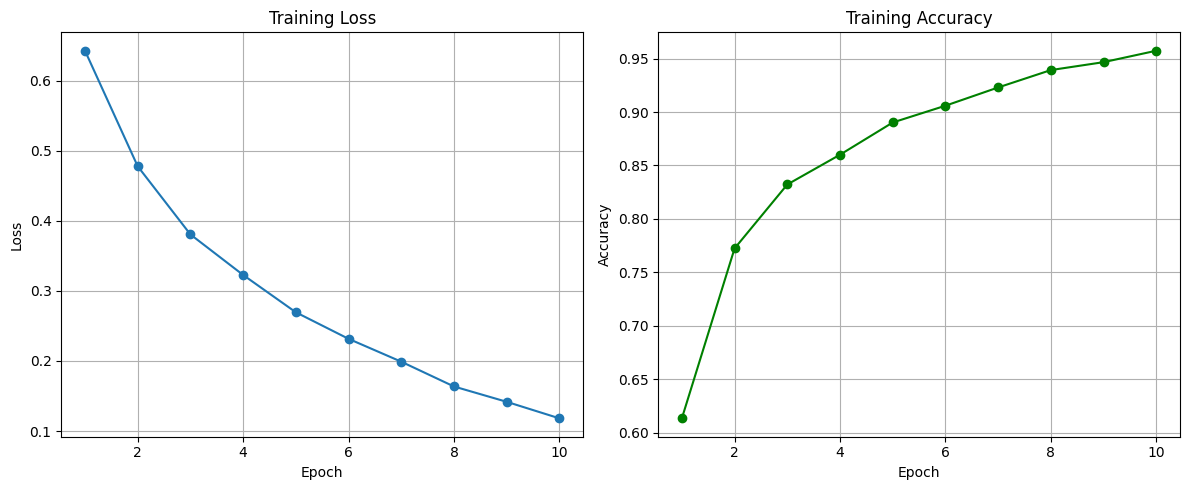


Evaluation Metrics:
Accuracy : 0.8082
Precision: 0.8412
Recall   : 0.7600
F1-Score : 0.7985


In [23]:
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_train, y_train, X_test, y_test, vocab = prepare_imdb_data()
    train_dl = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
    test_dl = DataLoader(TensorDataset(X_test, y_test), batch_size=128)

    embed_dim = 64
    embedding = nn.Embedding(10000, embed_dim)

    class IMDBDynamicModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = embedding
            self.ndlinear = DynamicNdLinear((200, embed_dim), (32, 16))
            self.classifier = nn.Linear(32 * 16, 2)

        def forward(self, x):
            x = self.embedding(x)
            x, _ = self.ndlinear(x)
            return self.classifier(x.view(x.size(0), -1)), _

    model = IMDBDynamicModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    loss_history, acc_history = [], []
    for epoch in range(1, 11):
        loss, acc = train_epoch(model, train_dl, optimizer, loss_fn, device)
        loss_history.append(loss)
        acc_history.append(acc)
        print(f"Epoch {epoch:2d} — Loss: {loss:.4f}, Acc: {acc:.4f}")

    plot_training_curves(loss_history, acc_history)
    evaluate(model, test_dl, device)

if __name__ == "__main__":
    main()